In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve

from ipywidgets import interact, FloatSlider


V min/max: 0.0 1.0
Mean electric field: -1.0
Mean current density: -0.5


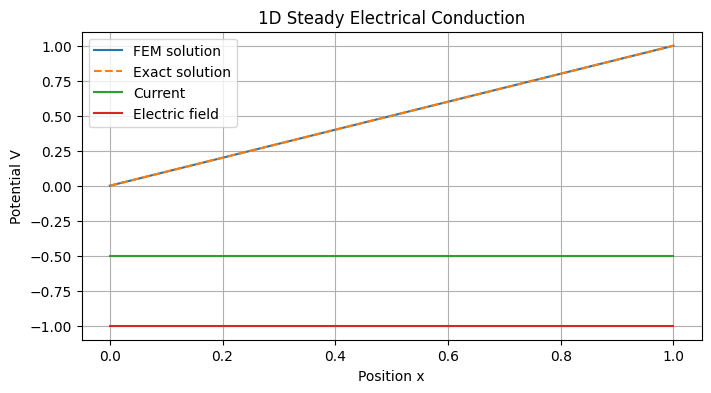

In [9]:

def FEM_element_based(sigma_values, L, Nx):
    h = L / (Nx - 1)

    K_global = np.zeros((Nx, Nx))

    for e in range(Nx - 1):
        sigma = sigma_values[e]
        K_e = (sigma / h) * np.array([[1, -1], [-1, 1]])
        K_global[e:e+2, e:e+2] += K_e

    return K_global, h


def BC_Solver(K_Full, L_BC, R_BC):

    Nx = K_Full.shape[0]
    # Potential
    V = np.zeros(Nx)
    V[0] =  L_BC
    V[-1] = R_BC

    # Reduced matrix
    K = csr_matrix(K_Full[1:-1, 1:-1])

    # RHS: no source in the PDE, but boundary values contribute
    b = np.zeros(Nx - 2)
    b[0]  -= K_Full[1,0]   * V[0]
    b[-1] -= K_Full[-2,-1] * V[-1]

    # Solve
    V_interior = spsolve(K, b)
    V[1:-1] = V_interior
    return V


# Parameters
L = 1.0
Nx = 50
x = np.linspace(0, L, Nx)

sigma_values = 0.5 * np.ones(Nx) # The conductivity parameter

# Assemble full matrix
K_full, h = FEM_element_based(sigma_values, L, Nx)

# Incorporate BC, and solve
V = BC_Solver(K_full, 0.0, 1.0)

# Derived quantities
E = -np.gradient(V, x)
J = sigma_values * E

print("V min/max:", V.min(), V.max())
print("Mean electric field:", np.mean(E))
print("Mean current density:", np.mean(J))

# Exact solution
V_exact = x / L

# Plot
plt.figure(figsize=(8, 4))
plt.plot(x, V, label='FEM solution')
plt.plot(x, V_exact, '--', label='Exact solution')
plt.plot(x, J, label='Current')
plt.plot(x, E, label='Electric field')
plt.xlabel('Position x')
plt.ylabel('Potential V')
plt.title('1D Steady Electrical Conduction')
plt.grid(True)
plt.legend()
#plt.savefig("./FEM/P1d.png", dpi=200)
plt.show()

The next goal is to make $\sigma$ dynamic, but we start with a simple artificial process of making it variable of some constant, let $x$

$$=> \sigma(x) = x^2$$

**Remark**: The properties should be assigned to elements, because nodes are the soutions, so:
$$x_i = \frac {x_{i-1} + x_{i+1}}{2}$$

# 1D Electrical Conduction with Variable Conductivity

We consider steady-state 1D electrical conduction with spatially varying conductivity:

$$
\frac{d}{dx} \left( \sigma(x)\frac{dV}{dx} \right) = 0
$$

with Dirichlet boundary conditions:

$$
V(0)=0, \quad V(L)=1
$$

Instead of a constant material property, we define:

$$
\sigma(x) = 1 + x^2
$$
  

In [10]:
# First we define a function
def sigma_x(x):
    return 1 + x**2

# Now we fill up the sigma 

x_node = np.linspace(0, L, Nx)
x_elem = 0.5 * x_node[:-1] + x_node[1:]

sigma_vals = sigma_x(x_elem)

# Assemble full matrix
K_full, h = FEM_element_based(sigma_vals, L, Nx)


# Incorporate BC, and solve
V = BC_Solver(K_full, 0.0, 1.0)


# Derived quantities
# element wise electric field
E = -(V[1:] - V[:-1])/h
#E = -np.gradient(V, x)
J = sigma_vals * E


print("V min/max:", V.min(), V.max())
print("Mean electric field:", np.mean(E))
print("Mean current density:", np.mean(J))


# Exact solution
V_exact = x / L



V min/max: 0.0 1.0
Mean electric field: -1.0000000000000002
Mean current density: -1.5317555586831506


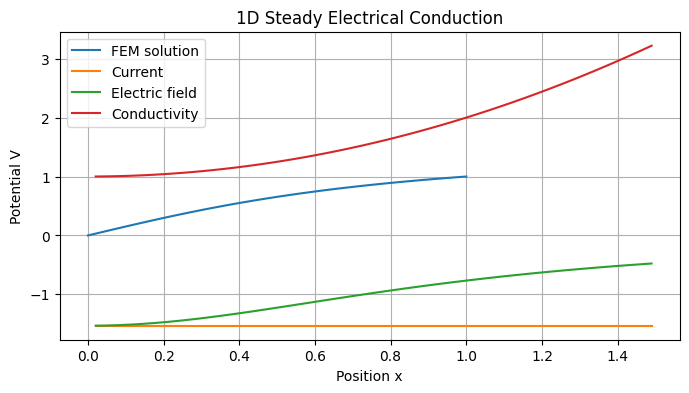

In [11]:
# Plot
plt.figure(figsize=(8, 4))
plt.plot(x_node, V, label='FEM solution')
#plt.plot(x, V_exact, '--', label='Exact solution')
plt.plot(x_elem, J, label='Current')
plt.plot(x_elem, E, label='Electric field')
plt.plot(x_elem,sigma_vals, label='Conductivity')
plt.xlabel('Position x')
plt.ylabel('Potential V')
plt.title('1D Steady Electrical Conduction')
plt.grid(True)
plt.legend()
#plt.savefig("./FEM/P1d.png", dpi=200)
plt.show()

Perhaps a normalization would help to analyze better.

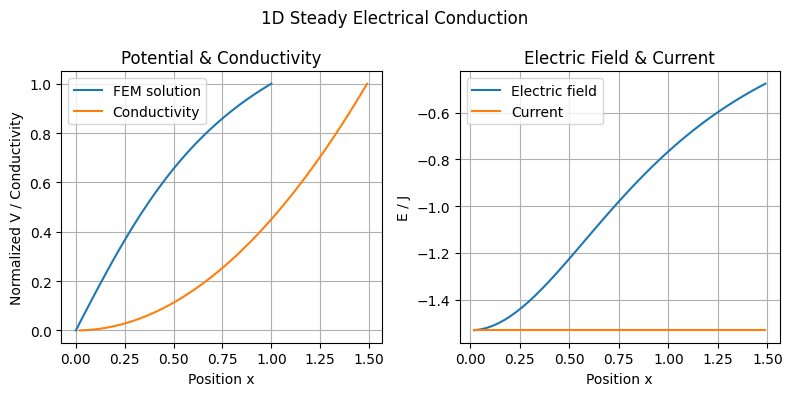

In [12]:
sigma_norm = (sigma_vals - sigma_vals.min()) / (sigma_vals.max() - sigma_vals.min())
V_norm = (V - V.min()) / (V.max() - V.min())
# E_norm = (E - E.min()) / (E.max() - E.min())
# J_norm = (J - J.min()) / (J.max() - J.min())
# print(sigma_norm)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(8, 4))  # CORRECTED: use subplots()

axs[0].plot(x_node, V_norm, label='FEM solution')
axs[0].plot(x_elem, sigma_norm, label='Conductivity')
# axs[0].plot(x, V_exact, '--', label='Exact solution')

axs[1].plot(x_elem, E, label='Electric field')
axs[1].plot(x_elem, J, label='Current')

# Labels and titles
axs[0].set_xlabel('Position x')
axs[0].set_ylabel('Normalized V / Conductivity')
axs[0].set_title('Potential & Conductivity')
axs[0].grid(True)
axs[0].legend()

axs[1].set_xlabel('Position x')
axs[1].set_ylabel('E / J')
axs[1].set_title('Electric Field & Current')
axs[1].grid(True)
axs[1].legend()

fig.suptitle('1D Steady Electrical Conduction')
fig.tight_layout()  # Prevents overlap
# plt.savefig("./FEM/P1d.png", dpi=200)
plt.show()  # CORRECTED: use plt.show() instead of fig.show()

In [13]:
print("J variation:", J.max() - J.min())

J variation: 9.725553695716371e-14


In modeling electromechanical transport, it is important to distinguish between **geometric effects** and **material effects**. Geometric changes arise from deformation of the domain (e.g., changes in length $L$ or area $A$), which influence quantities like resistance through relations such as $R = \frac{L}{A\sigma}$. In contrast, material effects describe how intrinsic properties, such as the electrical conductivity $\sigma$, change due to deformation. In semiconductors, this latter effect—known as **piezoresistivity**—is often dominant.

To describe this, conductivity is treated as a function of strain:
$$
\sigma = \sigma(\varepsilon)
$$
where $\varepsilon$ represents the mechanical strain. The exact functional dependence is generally unknown or too complex to derive directly from microscopic physics. However, for small deformations, it is reasonable to assume that $\sigma(\varepsilon)$ is smooth and can be approximated locally using a Taylor expansion:
$$
\sigma(\varepsilon) \approx \sigma_0 + \frac{d\sigma}{d\varepsilon}\varepsilon + \frac{1}{2}\frac{d^2\sigma}{d\varepsilon^2}\varepsilon^2 + \dots
$$

Factoring out the reference conductivity $\sigma_0$ yields:
$$
\sigma(\varepsilon) = \sigma_0 \left( 1 + \pi \varepsilon + \alpha \varepsilon^2 + \dots \right)
$$
where $\pi$ is the **linear piezoresistive coefficient** and $\alpha$ captures higher-order nonlinear effects. This expansion is not geometric in nature; rather, it approximates how the **internal electronic transport properties** respond to deformation.

Physically, strain modifies the crystal lattice, which in turn alters band structure, carrier mobility, and scattering mechanisms. These changes affect quantities such as the relaxation time $\tau$, and since conductivity is related to transport properties (e.g., $\sigma \sim \tau$), it becomes strain-dependent. Thus, the Taylor expansion provides a systematic way to capture this coupling between mechanics and transport without requiring a full microscopic derivation.

In [14]:
# Strain model
# Later replace this with FEM strain
def strain_field(x_elem, eps0):
    return eps0 * np.sin(np.pi * x_elem)

# Conductivity model
# sigma(eps) = sigma0(1 + pi eps + alpha eps^2)
def sigma_from_strain(eps_elem, sigma0, pi_coeff, alpha):
    return sigma0 * (1 + pi_coeff * eps_elem + alpha * eps_elem**2)


# Run model
def run_model(sigma0=0.5, pi_coeff=10.0, alpha=0.0, eps0=0.01):
    L = 1.0
    Nx = 100

    x_node = np.linspace(0, L, Nx)
    x_elem = 0.5 * (x_node[:-1] + x_node[1:])

    eps_elem = strain_field(x_elem, eps0)
    sigma_elem = sigma_from_strain(eps_elem, sigma0, pi_coeff, alpha)

    if np.any(sigma_elem <= 0):
        print("Unphysical choice: conductivity became non-positive.")
        print("sigma min:", sigma_elem.min())
        return

    K_full, h = FEM_element_based(sigma_elem, L, Nx)
    V = BC_Solver(K_full, 0.0, 1.0)

    E_elem = -(V[1:] - V[:-1]) / h
    J_elem = sigma_elem * E_elem

    print("sigma min/max:", sigma_elem.min(), sigma_elem.max())
    print("V min/max:", V.min(), V.max())
    print("Mean electric field:", E_elem.mean())
    print("Mean current density:", J_elem.mean())
    print("J variation:", J_elem.max() - J_elem.min())

    # Plot 1: strain and conductivity
    plt.figure(figsize=(8, 4))
    plt.plot(x_elem, eps_elem, label="Strain ε(x)")
    plt.plot(x_elem, sigma_elem, label="Conductivity σ(ε)")
    plt.xlabel("Position x")
    plt.ylabel("Value")
    plt.title("Strain-Dependent Conductivity")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot 2: potential
    plt.figure(figsize=(8, 4))
    plt.plot(x_node, V, label="Potential V")
    plt.xlabel("Position x")
    plt.ylabel("Potential V")
    plt.title("Voltage Solution")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot 3: transport quantities
    plt.figure(figsize=(8, 4))
    plt.plot(x_elem, E_elem, label="Electric field E")
    plt.plot(x_elem, J_elem, label="Current density J")
    plt.xlabel("Position x")
    plt.ylabel("Value")
    plt.title("Electric Field and Current Density")
    plt.grid(True)
    plt.legend()
    plt.show()

# parameter study
interact(
    run_model,
    sigma0=FloatSlider(min=0.1, max=2.0, step=0.1, value=0.5),
    pi_coeff=FloatSlider(min=-50, max=50, step=1, value=0),
    alpha=FloatSlider(min=-500, max=500, step=10, value=0),
    eps0=FloatSlider(min=0.0, max=0.1, step=0.005, value=0.01)
)

interactive(children=(FloatSlider(value=0.5, description='sigma0', max=2.0, min=0.1), FloatSlider(value=0.0, d…

<function __main__.run_model(sigma0=0.5, pi_coeff=10.0, alpha=0.0, eps0=0.01)>

The parametric study of the conductivity model 
$$
\sigma(\varepsilon)=\sigma_0\left(1+\pi_{\text{coeff}}\varepsilon+\alpha\varepsilon^2\right)
$$
reveals a clear separation between uncoupled and coupled behavior. When $\pi_{\text{coeff}}=\alpha=0$, the system reduces to a constant conductivity case $\sigma=\sigma_0$, leading to a linear potential $V(x)$, constant electric field $E(x)$, and uniform current density $J(x)$. In this regime, strain exists but has no influence on transport, providing a consistent baseline for validation.

Introducing a nonzero $\pi_{\text{coeff}}$ activates linear piezoresistive coupling, whereby conductivity responds directly to strain. This results in a redistribution of the electric field, producing a nonlinear potential profile while preserving current conservation, i.e.,
$$
\frac{dJ}{dx}=0.
$$
The magnitude and sign of $\pi_{\text{coeff}}$ control the sensitivity and direction of this response, determining whether conductivity increases or decreases under deformation.

The inclusion of the quadratic term $\alpha \varepsilon^2$ captures nonlinear effects that become significant at higher strain levels. While typically secondary for small $\varepsilon$, this term enhances curvature in the conductivity profile and introduces stronger spatial variations in $E(x)$ and $V(x)$. Care must be taken to ensure that $\sigma(\varepsilon)>0$ for all admissible strains, preserving physical validity.

Across all tested configurations, the numerical results confirm that the current density remains constant up to machine precision, validating the FEM implementation. The study demonstrates that the system maintains equilibrium by compensating variations in conductivity with corresponding adjustments in the electric field, reflecting the fundamental transport relation $J=\sigma E$.

Reasonable parameter choices for stable exploration include $\sigma_0 \in [0.1,2.0]$, $\pi_{\text{coeff}} \in [5,20]$, $\alpha \in [0,100]$, and strain amplitudes $\varepsilon \sim 10^{-3}$ to $10^{-2}$. Within this regime, the model captures both linear and nonlinear piezoresistive effects while remaining numerically robust and physically interpretable.